In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/ec2_latency.csv", parse_dates=["timestamp"])
print(df.shape)
print(df.head())
print(df.describe())
print("Missing values:", df.isna().sum().sum())
print("Time range:", df.timestamp.min(), "to", df.timestamp.max())

(4032, 2)
            timestamp   value
0 2014-03-07 03:41:00  45.868
1 2014-03-07 03:46:00  47.606
2 2014-03-07 03:51:00  42.580
3 2014-03-07 03:56:00  46.030
4 2014-03-07 04:01:00  44.992
                        timestamp        value
count                        4032  4032.000000
mean   2014-03-14 03:40:14.434524    45.155874
min           2014-03-07 03:41:00    22.864000
25%           2014-03-10 15:39:45    43.944000
50%           2014-03-14 03:38:30    45.017000
75%           2014-03-17 15:42:15    46.362000
max           2014-03-21 03:41:00    99.248000
std                           NaN     2.287089
Missing values: 0
Time range: 2014-03-07 03:41:00 to 2014-03-21 03:41:00


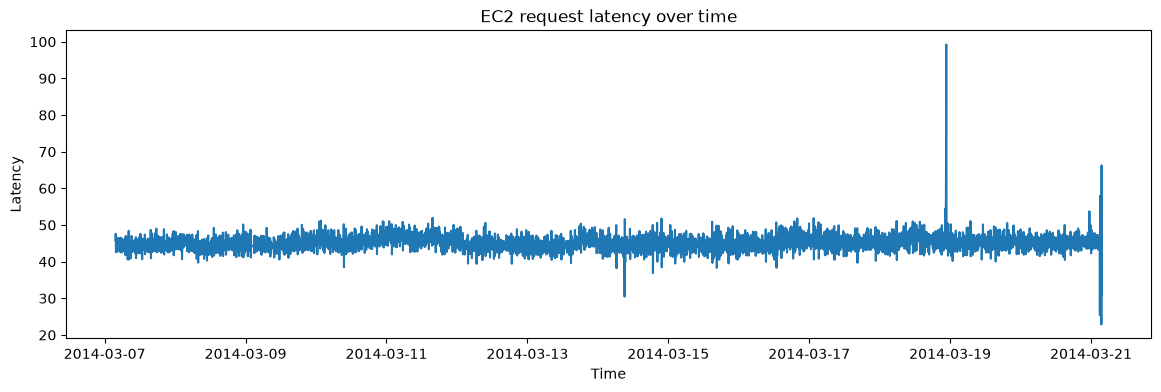

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(df.timestamp, df.value)
plt.title("EC2 request latency over time")
plt.xlabel("Time")
plt.ylabel("Latency")
plt.show()

[['2014-03-14 03:31:00.000000', '2014-03-14 14:41:00.000000'], ['2014-03-18 17:06:00.000000', '2014-03-19 04:16:00.000000'], ['2014-03-20 21:26:00.000000', '2014-03-21 03:41:00.000000']]


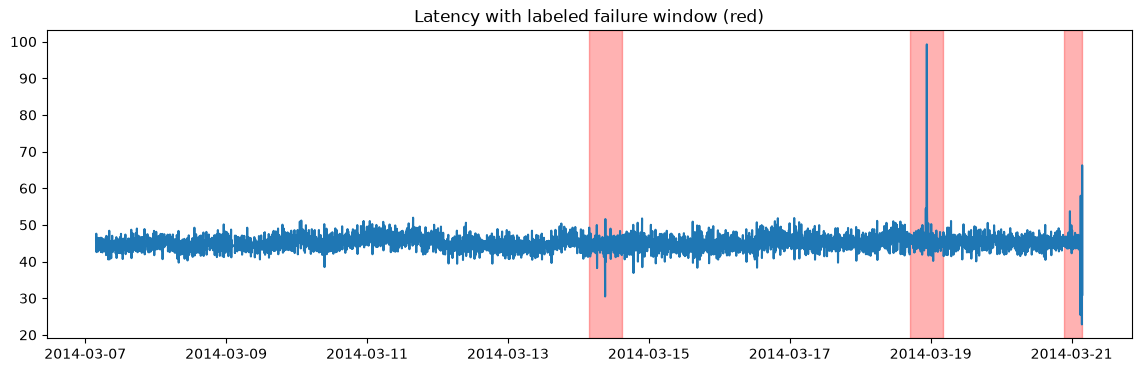

In [8]:
import json
labels = json.load(open("data/raw/labels.json"))
windows = labels["realKnownCause/ec2_request_latency_system_failure.csv"]
print(windows)

plt.figure(figsize=(14, 4))
plt.plot(df.timestamp, df.value)
for start, end in windows:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color="red", alpha=0.3)
plt.title("Latency with labeled failure window (red)")
plt.show()